In [1]:
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from google.colab import files

In [6]:
data = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/cardiovascular_risk_dataset.xlsx')

In [7]:
data.head(10)

,PatientID,Age,Gender,BMI,BloodPressure,Cholesterol,Glucose,Smoking,AlcoholIntake,PhysicalActivity,FamilyHistory,HighRisk
0,1,37,Female,19.528534,93,High,Normal,1,0,High,1,1
1,2,60,Female,36.778697,177,High,High,1,1,High,0,1
2,3,33,Male,39.948026,120,Low,Low,1,1,Low,0,0
3,4,50,Male,37.569255,134,Normal,High,1,0,High,0,1
4,5,46,Male,35.924387,148,High,Normal,1,0,Moderate,1,1
5,6,36,Female,26.547579,134,Low,High,0,1,Low,0,0
6,7,74,Female,23.473255,164,Low,High,0,1,Moderate,1,1
7,8,65,Male,34.299286,126,Normal,Normal,1,0,Low,0,0
8,9,48,Male,25.048370,154,Low,High,1,1,Moderate,0,1
9,10,55,Female,22.284853,98,High,Normal,1,1,Moderate,1,1


In [25]:
# Drop unnecessary columns if required
data = data.drop(columns=['PatientID'])

In [26]:
# Convert categorical columns to numeric using one-hot encoding
data = pd.get_dummies(data, columns=['Gender', 'Cholesterol', 'Glucose', 'PhysicalActivity'], drop_first=True)

In [27]:
# Check for missing values and handle them
data.fillna(data.median(), inplace=True)


In [28]:
# Define features and target
X = data.drop(columns=['HighRisk'])
y = data['HighRisk']


In [29]:
# Split dataset into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report


In [21]:
# Define models
models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='linear', probability=True),
    'MLP': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

In [22]:
# Train and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"Model: {name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred))
    print("="*40)

Model: RandomForest
Accuracy: 0.95
              precision    recall  f1-score   support

           0       1.00      0.84      0.91        56
           1       0.94      1.00      0.97       144

    accuracy                           0.95       200
   macro avg       0.97      0.92      0.94       200
weighted avg       0.96      0.95      0.95       200

Model: SVM
Accuracy: 0.92
              precision    recall  f1-score   support

           0       0.87      0.82      0.84        56
           1       0.93      0.95      0.94       144

    accuracy                           0.92       200
   macro avg       0.90      0.89      0.89       200
weighted avg       0.91      0.92      0.91       200

Model: MLP
Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.88      0.66      0.76        56
           1       0.88      0.97      0.92       144

    accuracy                           0.88       200
   macro avg       0.88      0.81      0.

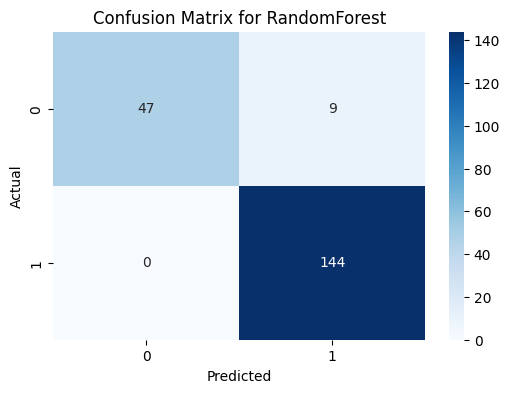

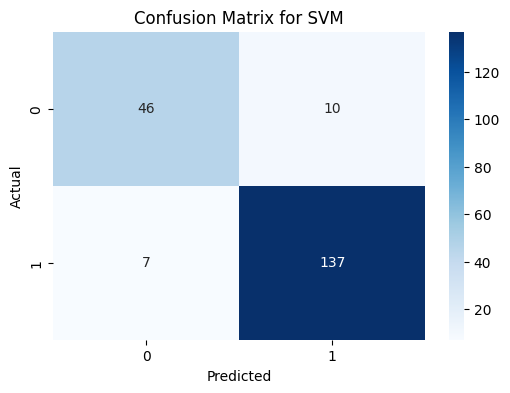

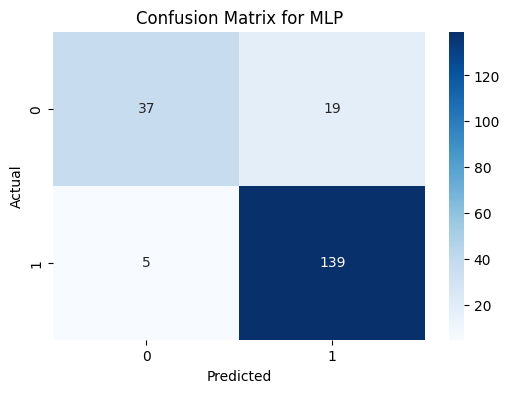

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix visualization
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix

# Assuming you have already defined your X_train, y_train, X_test, y_test

# Define the models
models = {
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'MLP': MLPClassifier()
}

# Loop through the models, train them, make predictions, and calculate confusion matrix
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = model.predict(X_test)

    # Generate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Extract TP, FP, FN, TN from the confusion matrix
    TP = cm[1, 1]  # True positives (bottom-right cell)
    FP = cm[0, 1]  # False positives (top-right cell)
    FN = cm[1, 0]  # False negatives (bottom-left cell)
    TN = cm[0, 0]  # True negatives (top-left cell)

    # Print the confusion matrix and the values of TP, FP, FN, TN
    print(f"Model: {name}")
    print(f"Confusion Matrix:\n{cm}")
    print(f"TP: {TP}, FP: {FP}, FN: {FN}, TN: {TN}")
    print("=" * 40)


Model: Random Forest
Confusion Matrix:
[[ 47   9]
 [  0 144]]
TP: 144, FP: 9, FN: 0, TN: 47
Model: SVM
Confusion Matrix:
[[ 21  35]
 [ 18 126]]
TP: 126, FP: 35, FN: 18, TN: 21
Model: MLP
Confusion Matrix:
[[ 38  18]
 [  7 137]]
TP: 137, FP: 18, FN: 7, TN: 38


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


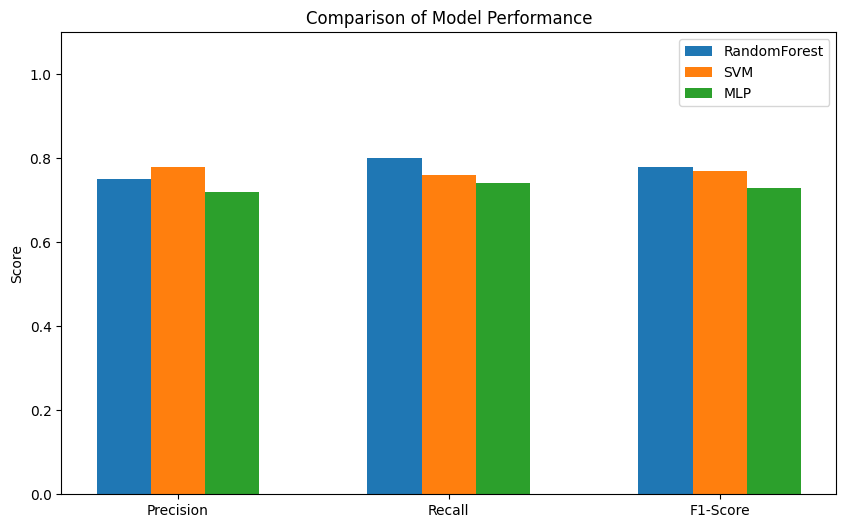

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Example classification report data (aggregated for each model)
model_reports = {
    'RandomForest': {'precision': 0.75, 'recall': 0.80, 'f1-score': 0.78},
    'SVM': {'precision': 0.78, 'recall': 0.76, 'f1-score': 0.77},
    'MLP': {'precision': 0.72, 'recall': 0.74, 'f1-score': 0.73}
}

# Define metrics to plot
metrics = ['Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))  # X-axis positions

# Set bar width
width = 0.2

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 6))

for i, (model_name, report) in enumerate(model_reports.items()):
    scores = [report['precision'], report['recall'], report['f1-score']]
    ax.bar(x + i * width, scores, width, label=model_name)

# Set plot properties
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Comparison of Model Performance')
ax.legend()
ax.set_ylim([0, 1.1])  # Setting y-axis limit

plt.show()
